<ipython-input-15-5251b85e215f>:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


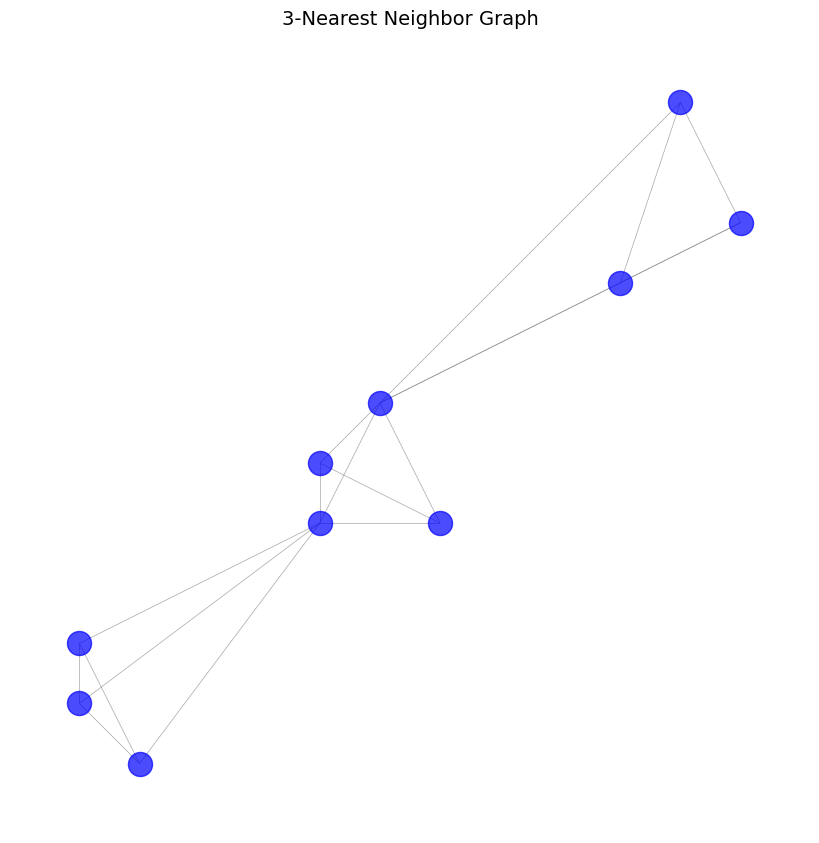

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
import networkx as nx

# === Config ===
#filename = "nodes.txt"
filename = "nodes2.txt"
k = 3  # Number of nearest neighbors

# === Read node from file ===
nodes = np.loadtxt(filename)
x, y = nodes[:, 0], nodes[:, 1]

# === Build k-NN graph ===
nbrs = NearestNeighbors(n_neighbors=k + 1, algorithm='auto').fit(nodes)
distances, indices = nbrs.kneighbors(nodes)

edges = []
edge_weights = []

for i, neighbors in enumerate(indices):
    for j_idx in neighbors[1:]:
        point_i = nodes[i]
        point_j = nodes[j_idx]
        weight = np.linalg.norm(point_i - point_j)

        edges.append((i, j_idx))
        edge_weights.append(weight)

# Save edge list with weights
#with open("knn_edges.txt", "w") as f:
#    for (i, j), w in zip(edges, edge_weights):
#        f.write(f"{i} {j} {w:.4f}\n")


G = nx.Graph()
for i, point in enumerate(nodes):
    G.add_node(i, pos=tuple(point))

G.add_edges_from(edges)

# Drawing
pos = nx.get_node_attributes(G, 'pos')
x, y = np.array(list(pos.values())).T

plt.figure(figsize=(10, 8))
nx.draw(G, pos, node_size=300, node_color='blue', edge_color='gray', width=0.5, alpha=0.7, with_labels=False)

plt.xticks([])
plt.yticks([])
plt.box(False)
plt.title(f"{k}-Nearest Neighbor Graph", fontsize=14)
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()


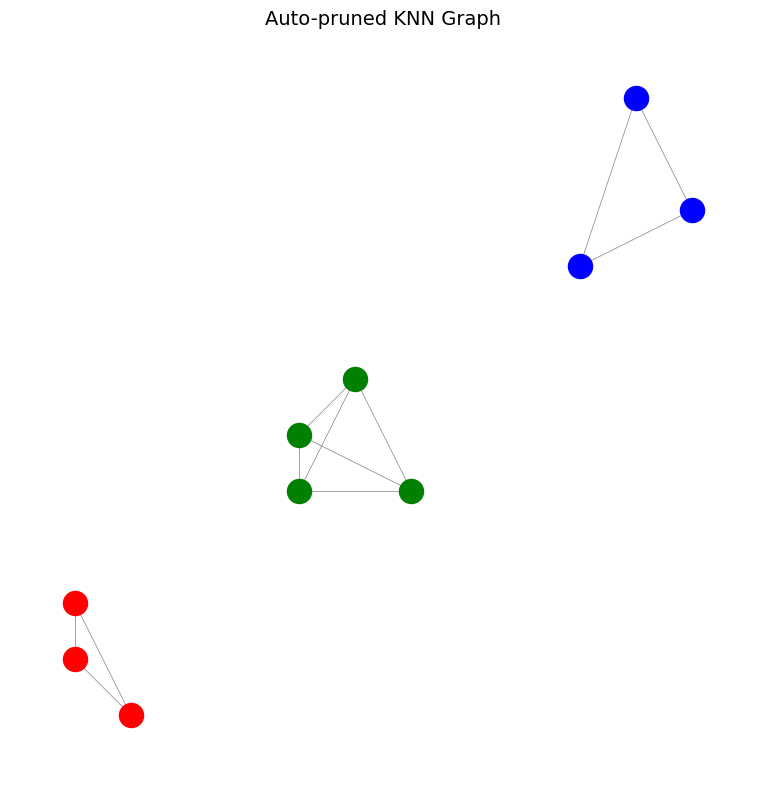

In [ ]:
# === Auto edge pruning ===

def auto_prune_edges(G, nodes, density_threshold=0.5, min_components=2):
    G_cut = G.copy()

    edges_sorted = sorted(G_cut.edges(data=True), key=lambda e: np.linalg.norm(
        nodes[e[0]] - nodes[e[1]]), reverse=True)

    def component_density(subgraph):
        n = subgraph.number_of_nodes()
        m = subgraph.number_of_edges()
        if n <= 1:
            return 0
        return (2 * m) / (n * (n - 1))

    for u, v, _ in edges_sorted:
        G_cut.remove_edge(u, v)
        components = [G_cut.subgraph(c).copy() for c in nx.connected_components(G_cut)]

        # Kiểm tra nếu tất cả component đều "đủ đặc"
        densities = [component_density(comp) for comp in components]
        if all(d >= density_threshold for d in densities) and len(components) >= min_components:
            break

    return G_cut

# === Gọi hàm auto prune ===
G_cut = auto_prune_edges(G, nodes, density_threshold=0.5, min_components=2)

# === Vẽ kết quả ===
pos = nx.get_node_attributes(G_cut, 'pos')
components = list(nx.connected_components(G_cut))
colors = ['red', 'green', 'blue', 'purple', 'orange']

plt.figure(figsize=(10, 8))
for idx, comp in enumerate(components):
    nx.draw_networkx_nodes(G_cut, pos, nodelist=comp, node_color=colors[idx % len(colors)], node_size=300)
nx.draw_networkx_edges(G_cut, pos, edge_color='gray', width=0.5)

plt.xticks([])
plt.yticks([])
plt.box(False)
plt.title("Auto-pruned KNN Graph", fontsize=14)
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()


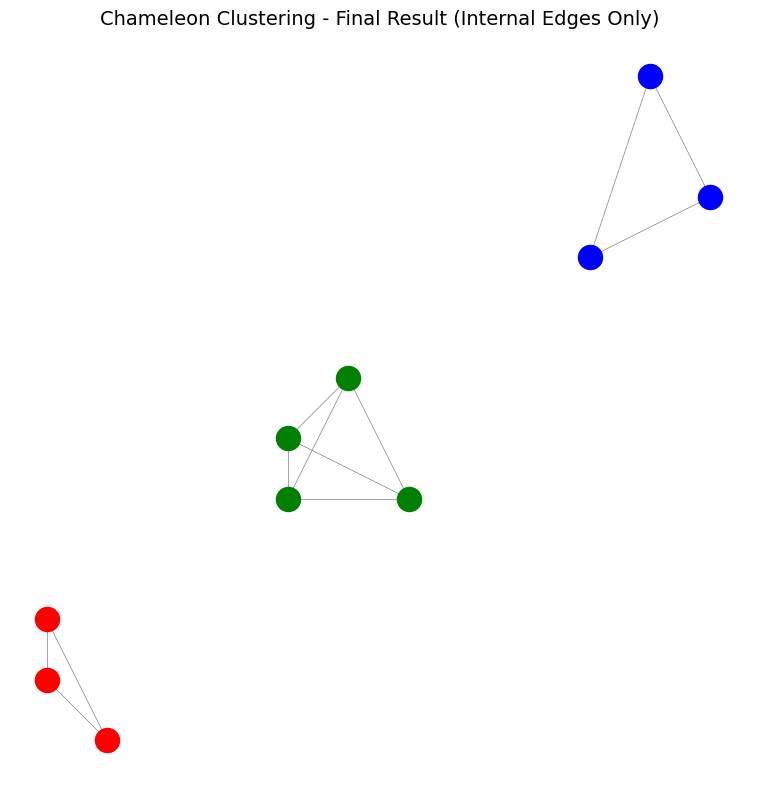

In [ ]:
# === RI and RC ===
def compute_EC(G, cluster):
    return sum(G[u][v].get('weight', 1.0)
               for u in cluster for v in cluster
               if G.has_edge(u, v) and u < v)

def compute_EC_between(G, c1, c2):
    return sum(G[u][v].get('weight', 1.0)
               for u in c1 for v in c2
               if G.has_edge(u, v))

def compute_RI_RC(G, c1, c2):
    ec_c1 = compute_EC(G, c1)
    ec_c2 = compute_EC(G, c2)
    ec_between = compute_EC_between(G, c1, c2)

    ri = ec_between / ((ec_c1 + ec_c2) / 2 + 1e-8)

    combined = c1.union(c2)
    ec_combined = compute_EC(G, combined)
    avg_combined = ec_combined / (len(combined)*(len(combined)-1)/2 + 1e-8)
    avg_sep = ((ec_c1 / (len(c1)*(len(c1)-1)/2 + 1e-8)) +
               (ec_c2 / (len(c2)*(len(c2)-1)/2 + 1e-8))) / 2

    rc = avg_combined / (avg_sep + 1e-8)

    return ri, rc, ri * rc


# === Merge ===
def chameleon_merge(G, initial_components, final_k=2):
    clusters = [set(c) for c in initial_components]

    while len(clusters) > final_k:
        merged_in_this_round = False

        for i in range(len(clusters)):
            for j in range(i + 1, len(clusters)):
                ri, rc, _ = compute_RI_RC(G, clusters[i], clusters[j])
                if ri > 1 and rc < 1:
                    merged = clusters[i].union(clusters[j])
                    clusters = [c for idx, c in enumerate(clusters) if idx not in (i, j)]
                    clusters.append(merged)
                    merged_in_this_round = True
                    break
            if merged_in_this_round:
                break

        if not merged_in_this_round:
            break

    return clusters


final_clusters = chameleon_merge(G, components, final_k=2)

# === Draw ===
plt.figure(figsize=(10, 8))
for idx, comp in enumerate(final_clusters):
    nx.draw_networkx_nodes(G, pos, nodelist=comp, node_color=colors[idx % len(colors)], node_size=300)

    subgraph = G.subgraph(comp)
    nx.draw_networkx_edges(subgraph, pos, edge_color='gray', width=0.5)

plt.xticks([])
plt.yticks([])
plt.box(False)
plt.title("Chameleon Clustering - Final Result (Internal Edges Only)", fontsize=14)
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

